# Zenith Core: an 8-bit RISC-V-inspired microcontroller with its own toolchain

Pablo José López Mazariegos, Guatemala
Project repository: https://github.com/PabloJLM/Zenith-Core
Submitted to the IEEE SSCS Open-Source Ecosystem Code-a-Chip Travel Grant, ISSCC 2027
License: Apache License 2.0

## Summary

Zenith Core is a small microcontroller designed from scratch in Verilog for teaching and experimentation. It has a reduced RISC-V-style instruction set (16-bit instructions, 8 registers, 8-bit datapath), a six-state multi-cycle CPU that absorbs the one-cycle latency of a synchronous block RAM, and memory-mapped GPIO, UART transmitter and PWM peripherals.

Programs are loaded through a UART: a small loader writes the incoming instructions straight into the instruction memory, so changing the software never requires synthesising the FPGA again. The project includes its own assembler, a flashing tool, a graphical IDE (JoJoP IDE) and a simulation front-end. The design runs on a Sipeed Tang Nano 9K board.

This notebook reproduces the parts of the project that do not need hardware. It assembles four demo programs, loads each one through the serial protocol in an Icarus Verilog simulation, and analyses the resulting waveforms with Python. Section 6 also runs the Fibonacci program from a hex file in a second testbench and shows the same program under cocotb. The graphical tools are shown with screenshots. Everything that runs in the notebook uses open-source tools.

| Section | Content |
|---|---|
| 1 | Architecture |
| 2 | Environment setup |
| 3 | From assembly to binary |
| 4 | The serial loading protocol |
| 5 | CPU execution |
| 6 | Worked example: Fibonacci (serial loader, hex testbench, cocotb) |
| 7 | Peripherals: UART and PWM |
| 8 | Development tools and simulation front-end |
| 9 | Hardware validation |
| 10 | Limitations and future work |

## 1. Architecture

![Block diagram of Zenith Core](imgs/Microxd.png)

Figure 1. Block diagram: CPU, instruction memory (512 x 16 bit block RAM), data memory with the MMIO decoder, peripherals and the UART loader.

### 1.1 Instruction set

Instructions are 16 bits wide. There are eight registers, r0 to r7, and r0 always reads as zero. The datapath is 8 bits wide. Immediates are 4-bit signed values, so the usable range is -8 to +7.

| Type | Opcode [15:13] | Fields | Operation |
|---|---|---|---|
| ALU immediate (ADDI, ANDI, ...) | 000 | rd [12:10], rs1 [9:7], funct3 [6:4], imm4 [3:0] | rd = rs1 op imm |
| ALU register (ADD, SUB, AND, OR, XOR, SLL, SRL, SLT) | 001 | rd [12:10], rs1 [9:7], rs2 [6:4], funct3 [3:1] | rd = rs1 op rs2 |
| LOAD | 010 | rd, rs1, imm4 | rd = MEM[rs1 + imm] |
| STORE | 011 | rs2 [12:10], rs1 [9:7], imm4 | MEM[rs1 + imm] = rs2 |
| BEQ | 100 | rs1 [12:10], rs2 [9:7], imm4 | branch if equal, offset -8 to +7 |
| JAL | 101 | rd [12:10], target [8:0] | rd = PC + 1, PC = target |
| OUT | 110 | rs1 [9:7] | gpio_out = rs1 |
| JUMP | 111 | target [8:0] | PC = target (0 to 511) |

### 1.2 Multi-cycle CPU

Every instruction takes six clock cycles. The extra WAIT state exists because the instruction memory is a synchronous block RAM: the word requested in FETCH is only valid one cycle later.

```
FETCH  ->  WAIT  ->  DECODE  ->  EXEC  ->  MEM  ->  WB
```

FETCH sends the program counter to the RAM. WAIT waits for the RAM. DECODE captures the instruction word and reads the registers. EXEC runs the ALU. MEM performs the load, store or OUT. WB writes the result back and updates the program counter.

At 27 MHz this gives 27 / 6 = 4.5 MIPS. Section 5 measures the six cycles from the simulated waveform.

### 1.3 Data memory map

| Address | Register | Access | Description |
|---|---|---|---|
| 0x00 - 0x7F | RAM | R/W | 128 bytes |
| 0x80 | GPIO_OUT | W | output pins |
| 0x81 | GPIO_IN | R | input pins |
| 0x82 | GPIO_DIR | W | pin direction |
| 0x83 | UART_TX | W | byte to transmit |
| 0x84 | UART_STAT | R | bit 0 is set while the transmitter is busy |
| 0x85 | PWM_DUTY | W | duty cycle, 0 to 255 |
| 0x86 | PWM_CTRL | W | bit 0 enable, bit 1 invert |
| 0x87 | PWM_PRE | W | prescaler |

## 2. Environment setup

The simulation uses Icarus Verilog. The analysis uses Python with numpy, matplotlib and vcdvcd, a small parser for VCD waveform files. GTKWave can open the same VCD files for interactive inspection but it is not needed to run the notebook.

| Requirement | Tested with | Installation |
|---|---|---|
| Python | 3.12 | python.org |
| numpy, matplotlib, vcdvcd | recent releases | `pip install -r requirements.txt` |
| Icarus Verilog (iverilog and vvp) | 12.0 | Windows: installer from https://bleyer.org/icarus/ with "Add to PATH" ticked. Ubuntu and Colab: `apt-get install iverilog`. macOS: `brew install icarus-verilog` |

The first cell installs the Python packages and checks that Icarus Verilog is available. On Debian-based systems, including Colab, it installs it automatically. The second cell prints the system, Python and tool versions used for the run.

In [1]:
import platform, shutil, subprocess, sys

%pip install -q --root-user-action=ignore numpy matplotlib vcdvcd

if shutil.which("iverilog") is None and shutil.which("apt-get"):
    subprocess.run("apt-get -qq update && apt-get -qq install -y iverilog", shell=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
if shutil.which("iverilog") is None or shutil.which("vvp") is None:
    raise SystemExit("Icarus Verilog was not found. Install it (see the table above) and make sure "
                     "'iverilog' and 'vvp' are on the PATH, then restart the kernel.")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import datetime, importlib.metadata as md_
iv = subprocess.run(["iverilog", "-V"], capture_output=True, text=True).stdout.splitlines()[0]
print("Executed on :", datetime.date.today().isoformat())
print("System      :", platform.platform())
print("Python      :", platform.python_version())
print("Icarus      :", iv.split(" (")[0])
for pkg in ("numpy", "matplotlib", "vcdvcd"):
    print(f"{pkg:<12}:", md_.version(pkg))

Executed on : 2026-10-07
System      : Windows-11-10.0.26200-SP0
Python      : 3.12.7
Icarus      : Icarus Verilog version 12.0
numpy       : 2.5.3
matplotlib  : 3.11.2
vcdvcd      : 2.6.0


The next cell finds the project files. When the notebook is opened from a copy of this folder it uses them directly. Otherwise, for example in Colab, it downloads only this folder from the Code-a-Chip repository.

In [3]:
import subprocess, shutil, sys
from pathlib import Path

SUBDIR = Path("ISSCC27/submitted_notebooks/zenith-core")
REPOS = ["https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io",
         "https://github.com/PabloJLM/sscs-ose-code-a-chip.github.io"]

def locate_project():
    for cand in (Path("."), SUBDIR):
        if (cand / "rtl" / "cpu_core.v").exists():
            return cand.resolve()
    for url in REPOS:
        shutil.rmtree("_zc_repo", ignore_errors=True)
        r = subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none", "--sparse", url, "_zc_repo"],
                           capture_output=True, text=True)
        if r.returncode:
            continue
        subprocess.run(["git", "-C", "_zc_repo", "sparse-checkout", "set", str(SUBDIR)],
                       check=True, capture_output=True)
        if (Path("_zc_repo") / SUBDIR / "rtl" / "cpu_core.v").exists():
            return (Path("_zc_repo") / SUBDIR).resolve()
    raise RuntimeError("Could not find or fetch the Zenith Core project files")

ROOT = locate_project()
BUILD = ROOT / "build"
BUILD.mkdir(exist_ok=True)
print("Project folder:", ROOT.name)
print("RTL files     :", ", ".join(sorted(p.name for p in (ROOT / "rtl").glob("*.v"))))

Project folder: zenith-core
RTL files     : alu.v, cpu_core.v, data_memory.v, gpio.v, instruction_memory.v, microrv8_system.v, pwm.v, regfile.v, tang_nano_top.v, uart.v, uart_loader.v


### Compiling the system

`sim/tb_flash.v` is a testbench that plays the role of the host computer. It reads a binary program and sends it to the system's UART receive pin with the same 115200 baud, 8N1 protocol that `tools/uart_flash.py` uses on the real board, with the 27 MHz clock of the Tang Nano. Once the transfer ends it lets the CPU run and writes the waveforms to a VCD file.

In [4]:
RTL = ["alu", "regfile", "cpu_core", "instruction_memory", "data_memory",
       "gpio", "uart", "pwm", "uart_loader", "microrv8_system"]
srcs = ["sim/tb_flash.v"] + [f"rtl/{m}.v" for m in RTL]
r = subprocess.run(["iverilog", "-g2005", "-o", "build/tb_flash.vvp", *srcs],
                   cwd=ROOT, capture_output=True, text=True)
print("iverilog return code:", r.returncode, "(0 = compiled without errors)")
print(r.stderr.strip())

iverilog return code: 0 (0 = compiled without errors)



## 3. From assembly to binary

`tools/assembler.py` is a two-pass assembler. It resolves labels, supports the pseudo-instructions NOP and MOV, and writes a `.hex` file for simulation and a `.bin` file for the serial loader. The first example is a binary counter that writes its value to the GPIO and waits a short software delay.

In [5]:
print((ROOT / "programs" / "demo_contador.asm").read_text(encoding="utf-8"))

    ADDI r1, r0, 0
loop:
    ADDI r1, r1, 1
    OUT  r1
    ADDI r2, r0, 6
delay:
    ADDI r2, r2, -1
    BEQ  r2, r0, loop
    JUMP delay



In [6]:
def run_demo(asm_name, run_us):

    asm = ROOT / "programs" / asm_name
    stem = asm.stem
    r = subprocess.run([sys.executable, "tools/assembler.py", f"programs/{asm_name}",
                        "-o", f"build/{stem}.hex", "--binary"],
                       cwd=ROOT, capture_output=True, text=True, encoding="utf-8", errors="replace", check=True)
    data = (BUILD / f"{stem}.bin").read_bytes()
    (BUILD / f"{stem}_bytes.hex").write_text("\n".join(f"{b:02x}" for b in data) + "\n")
    n_instr = (len(data) - 4) // 2
    sim = subprocess.run(["vvp", "build/tb_flash.vvp", f"+BYTES=build/{stem}_bytes.hex", f"+NBYTES={len(data)}",
                          f"+RUN_US={run_us}", f"+VCD=build/{stem}.vcd", f"+DUMP_ROM={n_instr}"],
                         cwd=ROOT, capture_output=True, text=True, encoding="utf-8", errors="replace", check=True)
    rom = [int(l.split("=")[1], 16) for l in sim.stdout.splitlines() if l.startswith("ROM[")]
    return dict(stem=stem, listing=r.stdout, data=data, vcd=BUILD / f"{stem}.vcd", log=sim.stdout, rom=rom)

cnt = run_demo("demo_contador.asm", run_us=100)
lst = cnt["listing"]
print(lst[lst.index("=" * 10):])

MicroRV8-GT Assembly Listing
Addr      Hex            Binary  Source
------------------------------------------------------------------------
0x000  0x0400  000_001_000_000_0000  ADDI r1, r0, 0
0x001  0x0481  000_001_001_000_0001  ADDI r1, r1, 1
0x002  0xc080  110_000_001_000_0000  OUT r1
0x003  0x0806  000_010_000_000_0110  ADDI r2, r0, 6
0x004  0x090f  000_010_010_000_1111  ADDI r2, r2, -1
0x005  0x880b  100_010_000_000_1011  BEQ r2, r0, loop
0x006  0xe004  111_000_000_000_0100  JUMP delay
Total: 7 instrucciones



The listing gives, for each instruction, its address, its hexadecimal word, the binary word split into fields (opcode, rd, rs1, funct3, imm) and the source line. BEQ is encoded with a relative offset (1011 is -5 in the example), while JUMP carries an absolute 9-bit target.

## 4. The serial loading protocol

The loader (`rtl/uart_loader.v`) is a small state machine next to the instruction memory. While it receives a program it keeps the CPU in reset. When the last instruction has been written, it releases the CPU, which starts at address 0.

```
0xAA  0x55  count_hi  count_lo  instr0_hi  instr0_lo  instr1_hi  instr1_lo  ...
```

The link runs at 115200 baud with 8 data bits, no parity and one stop bit, so each byte is a 10-bit frame of 86.8 µs. The pair 0xAA 0x55 is a synchronisation header, and any other byte after 0xAA sends the state machine back to idle. The count is a 9-bit number of instructions (at most 512, the size of the memory), followed by the instructions, 16 bits each, most significant byte first.

To check this on the wire, the next cells load the counter program and decode the receive pin from the simulation with a small software UART receiver that does not depend on the testbench.

In [7]:
from IPython.display import Image, display, Markdown

def show(rel, caption, width=760):
    path = ROOT / rel
    if path.exists():
        display(Markdown(caption))
        display(Image(filename=str(path), width=width))

import numpy as np
import matplotlib.pyplot as plt
from vcdvcd import VCDVCD

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

BAUD = 115200
BIT_US = 1e6 / BAUD
CLK_MHZ = 27.0

def _to_int(s):
    return -1 if any(c in s for c in "xXzZ") else int(s, 2)

class Trace:

    def __init__(self, path):
        self.v = VCDVCD(str(path))
        self.ref = {}
        for full in self.v.signals:
            if full.startswith("tb_flash.") and full.count(".") == 1:
                self.ref[full[len("tb_flash."):].split("[")[0]] = full
    def sig(self, name):
        s = self.v[self.ref[name]]
        t = np.array([x[0] for x in s.tv], float) / 1e6
        y = np.array([_to_int(x[1]) for x in s.tv])
        return t, y

def value_at(t, y, when):
    return y[max(np.searchsorted(t, when, side="right") - 1, 0)]

def load_window(t, y):

    i0 = np.where(y == 1)[0][0]
    i1 = i0 + np.where(y[i0:] == 0)[0][0]
    return t[i0], t[i1]

def decode_uart(t, y, t_from=0.0):

    frames, pos = [], t_from
    while True:
        idx = np.where((t >= pos) & (y == 0))[0]
        if len(idx) == 0:
            break
        s = t[idx[0]]
        byte = sum(int(value_at(t, y, s + BIT_US * (k + 1.5))) << k for k in range(8))
        frames.append((s, byte))
        pos = s + BIT_US * 9.5
    return frames

tr = Trace(cnt["vcd"])
t_rx, y_rx = tr.sig("rx")
frames = decode_uart(t_rx, y_rx)

sent = list(cnt["data"])
got = [b for _, b in frames]
print(f"bytes in the .bin file : {len(sent)}")
print(f"bytes decoded from RX  : {len(got)}")
print("identical              :", sent == got)
print("header                 :", " ".join(f"0x{b:02X}" for b in got[:4]))

bytes in the .bin file : 18
bytes decoded from RX  : 18
identical              : True
header                 : 0xAA 0x55 0x00 0x07


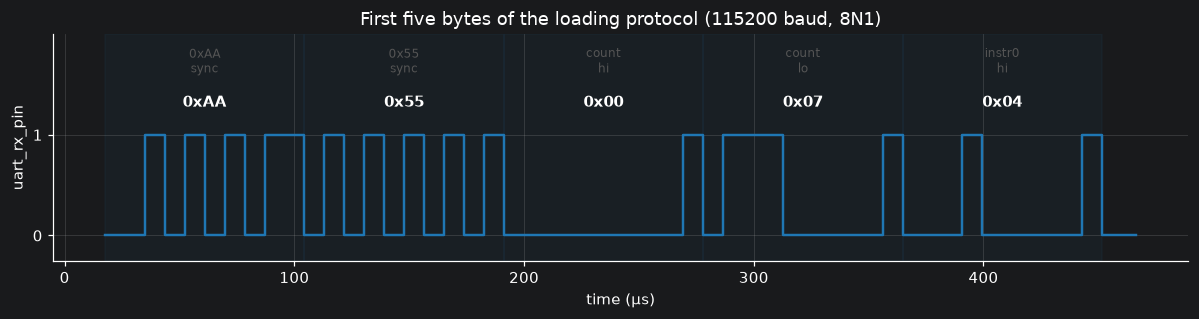

In [8]:
fig, ax = plt.subplots(figsize=(11, 3))
t0 = frames[0][0] - 15
t1 = frames[4][0] + 10 * BIT_US + 15
m = (t_rx >= t0) & (t_rx <= t1)
tt = np.append(t_rx[m], t1); yy = np.append(y_rx[m], y_rx[m][-1])
ax.step(tt, yy, where="post", color="#1f77b4", lw=1.6)
labels = ["0xAA\nsync", "0x55\nsync", "count\nhi", "count\nlo", "instr0\nhi"]
for (s, b), lab in zip(frames[:5], labels):
    ax.axvspan(s, s + 10 * BIT_US, color="#1f77b4", alpha=0.06)
    ax.text(s + 5 * BIT_US, 1.28, f"0x{b:02X}", ha="center", fontsize=10, fontweight="bold")
    ax.text(s + 5 * BIT_US, 1.62, lab, ha="center", fontsize=8, color="#555")
ax.set_ylim(-0.25, 2.0); ax.set_yticks([0, 1]); ax.set_yticklabels(["0", "1"])
ax.set_xlabel("time (µs)"); ax.set_ylabel("uart_rx_pin")
ax.set_title("First five bytes of the loading protocol (115200 baud, 8N1)")
plt.tight_layout(); plt.show()

Figure 2. Every byte is a frame with a start bit, eight data bits (least significant first) and a stop bit. The decoded bytes match the content of the `.bin` file, starting with the 0xAA 0x55 header.

The next figure shows the complete sequence for the counter program. At the start the instruction memory holds the factory firmware, a LED blinker, and the GPIO changes. When the loader sees 0xAA it raises `loader_active` and the CPU is held in reset, so the GPIO returns to 0. When the last instruction has been written the CPU restarts and runs the new program, with no synthesis step in between.

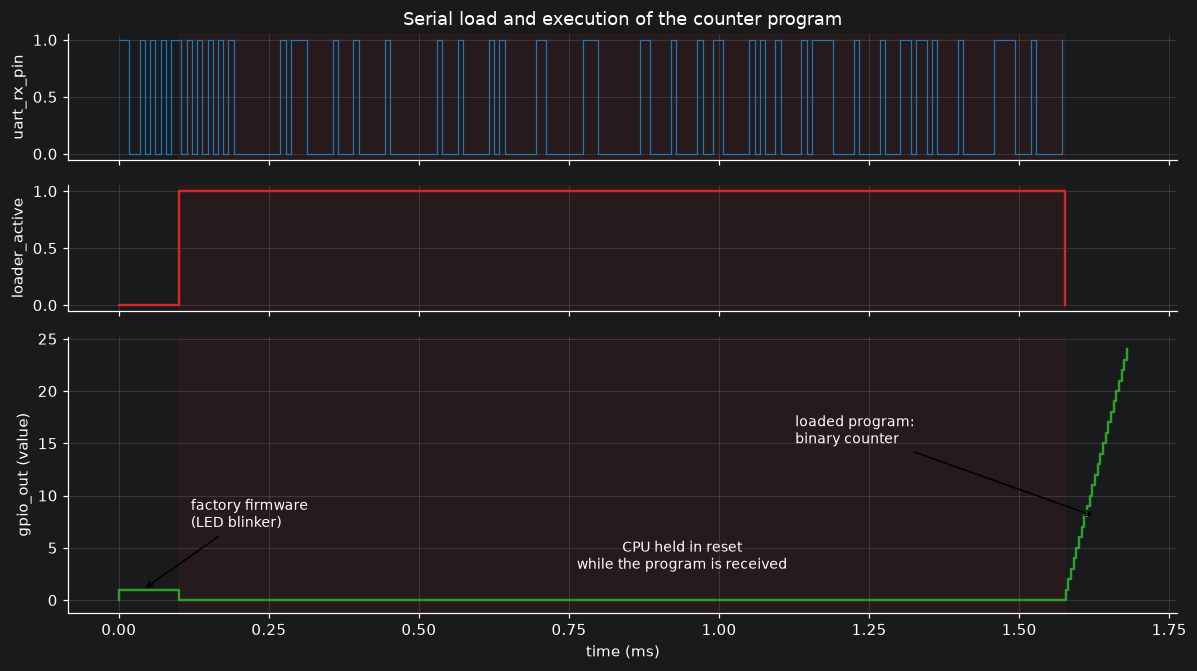

GPIO sequence after the load: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 ...


In [9]:
t_la, y_la = tr.sig("loader_active")
t_g, y_g = tr.sig("gpio_out")
t_load0, t_load1 = load_window(t_la, y_la)

fig, axs = plt.subplots(3, 1, figsize=(11, 6.2), sharex=True,
                        gridspec_kw={"height_ratios": [1, 1, 2.2]})
axs[0].step(t_rx / 1000, y_rx, where="post", color="#1f77b4", lw=0.8); axs[0].set_ylabel("uart_rx_pin")
axs[1].step(t_la / 1000, y_la, where="post", color="#d62728", lw=1.6); axs[1].set_ylabel("loader_active")
axs[2].step(t_g / 1000, y_g, where="post", color="#2ca02c", lw=1.6); axs[2].set_ylabel("gpio_out (value)")
axs[2].set_xlabel("time (ms)")
for a in axs:
    a.axvspan(t_load0 / 1000, t_load1 / 1000, color="#d62728", alpha=0.07)
axs[0].set_title("Serial load and execution of the counter program")
axs[2].annotate("factory firmware\n(LED blinker)", xy=(0.04, 1), xytext=(0.12, 7), arrowprops=dict(arrowstyle="->"), fontsize=9)
axs[2].text((t_load0 + t_load1) / 2000 + 0.1, 3, "CPU held in reset\nwhile the program is received", ha="center", fontsize=9)
axs[2].annotate("loaded program:\nbinary counter", xy=(t_load1 / 1000 + 0.05, 8), xytext=(t_load1 / 1000 - 0.45, 15),
                arrowprops=dict(arrowstyle="->"), fontsize=9)
plt.tight_layout(); plt.show()

vals = y_g[t_g > t_load1]
print("GPIO sequence after the load:", " ".join(str(v) for v in vals[:16]), "...")

Figure 3. The CPU stays in reset while the program is being received and then runs the new program.

## 5. CPU execution

The testbench exports `debug_state`, `debug_pc` and `debug_instr`. The next cell disassembles instruction words and plots the state machine over the first instructions executed after the load.

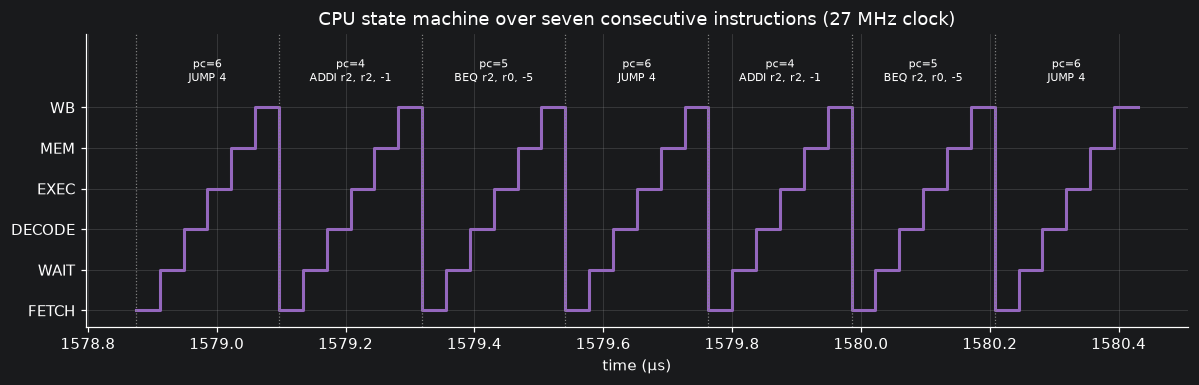

In [10]:
def disasm(w):
    op, rd, rs1 = (w >> 13) & 7, (w >> 10) & 7, (w >> 7) & 7
    f3, imm = (w >> 4) & 7, w & 15
    sx = imm - 16 if imm >= 8 else imm
    alu = ["ADD", "SUB", "AND", "OR", "XOR", "SLL", "SRL", "SLT"]
    if op == 0: return f"{alu[f3]}I r{rd}, r{rs1}, {sx}"
    if op == 1: return f"{alu[(w >> 1) & 7]} r{rd}, r{rs1}, r{f3}"
    if op == 2: return f"LOAD r{rd}, r{rs1}, {sx}"
    if op == 3: return f"STORE r{rd}, r{rs1}, {sx}"
    if op == 4: return f"BEQ r{rd}, r{rs1}, {sx:+d}"
    if op == 5: return f"JAL r{rd}, {w & 0x1FF}"
    if op == 6: return f"OUT r{rs1}"
    return f"JUMP {w & 0x1FF}"

t_st, y_st = tr.sig("debug_state")
t_pc, y_pc = tr.sig("debug_pc")
t_ir, y_ir = tr.sig("debug_instr")
STATES = ["FETCH", "WAIT", "DECODE", "EXEC", "MEM", "WB"]

t_run = load_window(t_la, y_la)[1] + 2
t_run = t_st[np.searchsorted(t_st, t_run)]
w0, w1 = t_run, t_run + 7 * 6 / CLK_MHZ
m = (t_st >= w0) & (t_st <= w1)
tt = np.append(t_st[m], w1); yy = np.append(y_st[m], y_st[m][-1])

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.step(tt, yy, where="post", color="#9467bd", lw=2)
ax.set_yticks(range(6)); ax.set_yticklabels(STATES)
ax.set_xlabel("time (µs)")
ax.set_title("CPU state machine over seven consecutive instructions (27 MHz clock)")

starts = [tt[i] for i in range(len(tt) - 1) if yy[i] == 0 and (i == 0 or yy[i - 1] != 0)]
for s in starts:
    ax.axvline(s, color="gray", ls=":", lw=0.8)
    pc = value_at(t_pc, y_pc, s + 5.5 / CLK_MHZ)
    ir = value_at(t_ir, y_ir, s + 5.5 / CLK_MHZ)
    ax.text(s + 3 / CLK_MHZ, 5.55, f"pc={pc}\n{disasm(ir)}", ha="center", va="bottom", fontsize=7.5)
ax.set_ylim(-0.4, 6.8)
plt.tight_layout(); plt.show()

In [11]:
fetch_times = t_st[np.where((y_st == 0) & (np.r_[True, y_st[:-1] != 0]))[0]]
fetch_times = fetch_times[fetch_times > t_run]
period_us = np.diff(fetch_times)[:100]
cpi = np.median(period_us) * CLK_MHZ
print(f"Median time between instructions: {np.median(period_us)*1000:.1f} ns")
print(f"Cycles per instruction (CPI)    : {cpi:.2f}")
print(f"Throughput at {CLK_MHZ:.0f} MHz            : {CLK_MHZ / cpi:.2f} MIPS")

Median time between instructions: 222.2 ns
Cycles per instruction (CPI)    : 6.00
Throughput at 27 MHz            : 4.50 MIPS


Figure 4 shows the six states of every instruction, and the measured values are 6.00 cycles per instruction and 4.50 MIPS at 27 MHz, as the architecture predicts. Branches and jumps take the same six cycles as any other instruction, so the duration of a software loop can be computed exactly.

## 6. Worked example: Fibonacci

This section follows one program through the whole chain: source code, machine code, bytes on the wire, instruction memory, execution and result. The program computes the first 14 Fibonacci numbers and sends each one to the GPIO with OUT. The largest value, 233, fits in the 8-bit datapath.

The program keeps the current term in r1, the next term in r2, a temporary value in r3 and the number of remaining terms in r4. It uses register-to-register arithmetic (ADD, and MOV, which the assembler translates to ADD rd, rs, r0), a conditional branch (BEQ) and an unconditional jump (JUMP). Since immediates only go up to +7, the counter 14 is built as 7 + 7.

In [12]:
print((ROOT / "programs" / "demo_fibonacci.asm").read_text(encoding="utf-8"))

    ADDI r1, r0, 0
    ADDI r2, r0, 1
    ADDI r4, r0, 7
    ADD  r4, r4, r4
loop:
    OUT  r1
    ADD  r3, r1, r2
    MOV  r1, r2
    MOV  r2, r3
    ADDI r4, r4, -1
    BEQ  r4, r0, done
    JUMP loop
done:
    JUMP done



### Assembly, loading and disassembly

After the transfer the testbench prints the first N words of the instruction memory, where N is the program length. Comparing them with the assembler output shows what the loader actually stored. The words read back from the memory are then disassembled, and the disassembly is assembled again to check that it produces the same machine code.

In [13]:
fib = run_demo("demo_fibonacci.asm", run_us=60)
lst = fib["listing"]
print(lst[lst.index("=" * 10):])

MicroRV8-GT Assembly Listing
Addr      Hex            Binary  Source
------------------------------------------------------------------------
0x000  0x0400  000_001_000_000_0000  ADDI r1, r0, 0
0x001  0x0801  000_010_000_000_0001  ADDI r2, r0, 1
0x002  0x1007  000_100_000_000_0111  ADDI r4, r0, 7
0x003  0x3240  001_100_100_100_0000  ADD r4, r4, r4
0x004  0xc080  110_000_001_000_0000  OUT r1
0x005  0x2ca0  001_011_001_010_0000  ADD r3, r1, r2
0x006  0x2500  001_001_010_000_0000  MOV r1, r2
0x007  0x2980  001_010_011_000_0000  MOV r2, r3
0x008  0x120f  000_100_100_000_1111  ADDI r4, r4, -1
0x009  0x9001  100_100_000_000_0001  BEQ r4, r0, done
0x00a  0xe004  111_000_000_000_0100  JUMP loop
0x00b  0xe00b  111_000_000_000_1011  JUMP done
Total: 12 instrucciones



In [14]:
words_asm = [int(l, 16) for l in (BUILD / "demo_fibonacci.hex").read_text().split()]
words_rom = fib["rom"]
print(f"words produced by the assembler          : {len(words_asm)}")
print(f"words read back from the instruction ROM  : {len(words_rom)}  (after the serial load)")
print("identical                                 :", words_asm == words_rom)

print(f"\n{'addr':<5}{'word':<7}{'op  rd  rs1 f3  imm':<22}disassembly (from the ROM contents)")
for a, w in enumerate(words_rom):
    b = f"{w:016b}"
    print(f"{a:<5}{w:04x}   {b[0:3]} {b[3:6]} {b[6:9]} {b[9:12]} {b[12:]:<5}  {disasm(w)}")

sys.path.insert(0, str(ROOT / "tools"))
from assembler import Assembler
text = "\n".join(disasm(w) for w in words_rom)
print("\nre-assembling the disassembly gives the same machine code:", Assembler().assemble(text) == words_rom)

words produced by the assembler          : 12
words read back from the instruction ROM  : 12  (after the serial load)
identical                                 : True

addr word   op  rd  rs1 f3  imm   disassembly (from the ROM contents)
0    0400   000 001 000 000 0000   ADDI r1, r0, 0
1    0801   000 010 000 000 0001   ADDI r2, r0, 1
2    1007   000 100 000 000 0111   ADDI r4, r0, 7
3    3240   001 100 100 100 0000   ADD r4, r4, r4
4    c080   110 000 001 000 0000   OUT r1
5    2ca0   001 011 001 010 0000   ADD r3, r1, r2
6    2500   001 001 010 000 0000   ADD r1, r2, r0
7    2980   001 010 011 000 0000   ADD r2, r3, r0
8    120f   000 100 100 000 1111   ADDI r4, r4, -1
9    9001   100 100 000 000 0001   BEQ r4, r0, +1
10   e004   111 000 000 000 0100   JUMP 4
11   e00b   111 000 000 000 1011   JUMP 11

re-assembling the disassembly gives the same machine code: True


### Execution

The next cell reads the GPIO while the loaded program runs and compares it with a reference computed in Python. The pins do not change when the program outputs the same value twice, which happens with F(1) and F(2), so the comparison is made against the reference with consecutive repeated values collapsed.

Fibonacci reference (Python)      : [0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233]
GPIO values seen in the waveform  : [0, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233]
match (repeats collapsed)         : True


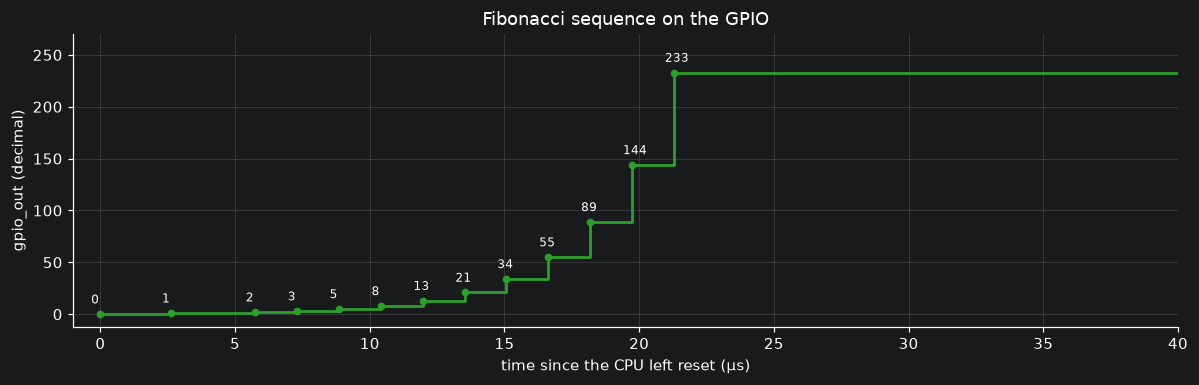

In [15]:
trf = Trace(fib["vcd"])
t_f, y_f = trf.sig("gpio_out")
t_lf, y_lf = trf.sig("loader_active")
t0 = load_window(t_lf, y_lf)[1]

seq_t = np.r_[t0, t_f[t_f > t0]] - t0
seq_v = np.r_[value_at(t_f, y_f, t0), y_f[t_f > t0]]

ref = [0, 1]
while len(ref) < 14:
    ref.append(ref[-1] + ref[-2])
collapse = lambda seq: [v for i, v in enumerate(seq) if i == 0 or v != seq[i - 1]]

print("Fibonacci reference (Python)      :", ref)
print("GPIO values seen in the waveform  :", [int(v) for v in seq_v])
print("match (repeats collapsed)         :", [int(v) for v in seq_v] == collapse(ref))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.step(np.append(seq_t, 40), np.append(seq_v, seq_v[-1]), where="post", color="#2ca02c", lw=1.8)
ax.plot(seq_t, seq_v, "o", color="#2ca02c", ms=4)
for t, v in zip(seq_t, seq_v):
    ax.annotate(str(int(v)), (t, v), textcoords="offset points", xytext=(-6, 7), fontsize=8)
ax.set_xlabel("time since the CPU left reset (µs)"); ax.set_ylabel("gpio_out (decimal)")
ax.set_xlim(-1, 40); ax.set_ylim(-12, 270)
ax.set_title("Fibonacci sequence on the GPIO")
plt.tight_layout(); plt.show()

Figure 5. The GPIO goes through 0, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144 and 233, and then the program stays in the final JUMP. The assembler output, the bytes sent over the serial link, the words stored in memory, their disassembly and the observed behaviour are consistent with each other.

### Hex file and testbench

The Compile button of JoJoP IDE runs the same assembler used in this notebook and writes a `.hex` file, with one 16-bit instruction word per line, and a `.bin` file next to the source. `sim/tb_fibo.v` is a second testbench that reads such a `.hex` file with `$readmemh` and loads it straight into the instruction memory, so it does not use the serial loader. It samples `gpio_out` in the write-back state of every OUT instruction, compares the 14 values with the Fibonacci numbers and checks that the program counter stops at the final JUMP.

Without arguments it looks for `programs/fibo.hex`, the file the IDE writes for the `fibo.asm` example of the project repository. Here the hex produced from `demo_fibonacci.asm` is passed with `+HEX=`.

In [16]:
r = subprocess.run(["iverilog", "-g2012", "-o", "build/tb_fibo.vvp", "sim/tb_fibo.v",
                    *[f"rtl/{m}.v" for m in RTL]],
                   cwd=ROOT, capture_output=True, text=True)
print("iverilog return code:", r.returncode)
print(r.stderr.strip())

hexfile = BUILD / "demo_fibonacci.hex"
print("hex file:", hexfile.name, hexfile.read_text().split())

run = subprocess.run(["vvp", "tb_fibo.vvp", "+HEX=demo_fibonacci.hex"],
                     cwd=BUILD, capture_output=True, text=True, encoding="utf-8", errors="replace")
print()
print(run.stdout)

iverilog return code: 0

hex file: demo_fibonacci.hex ['0400', '0801', '1007', '3240', 'c080', '2ca0', '2500', '2980', '120f', '9001', 'e004', 'e00b']

VCD info: dumpfile tb_fibo.vcd opened for output.
Programa cargado desde: demo_fibonacci.hex
  ROM[0] = 0400
  ROM[1] = 0801
  ROM[2] = 1007
  ROM[3] = 3240
  ROM[4] = c080
  ROM[5] = 2ca0
  ROM[6] = 2500
  ROM[7] = 2980
  ROM[8] = 120f
  ROM[9] = 9001
  ROM[10] = e004
  ROM[11] = e00b
Fibonacci
[9500.0 ns] Reset liberado
[39500.0 ns] OUT #1  gpio = 0 (0x00)  pc=4
[81500.0 ns] OUT #2  gpio = 1 (0x01)  pc=4
[123500.0 ns] OUT #3  gpio = 1 (0x01)  pc=4
[165500.0 ns] OUT #4  gpio = 2 (0x02)  pc=4
[207500.0 ns] OUT #5  gpio = 3 (0x03)  pc=4
[249500.0 ns] OUT #6  gpio = 5 (0x05)  pc=4
[291500.0 ns] OUT #7  gpio = 8 (0x08)  pc=4
[333500.0 ns] OUT #8  gpio = 13 (0x0d)  pc=4
[375500.0 ns] OUT #9  gpio = 21 (0x15)  pc=4
[417500.0 ns] OUT #10  gpio = 34 (0x22)  pc=4
[459500.0 ns] OUT #11  gpio = 55 (0x37)  pc=4
[501500.0 ns] OUT #12  gpio = 89 (0x

The hex file written by the IDE for the Fibonacci program: one instruction word per line.

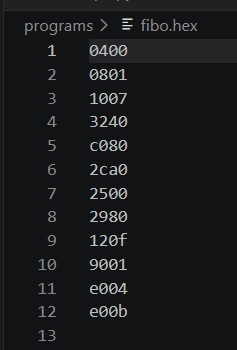

Part of sim/tb_fibo.v that locates the hex file.

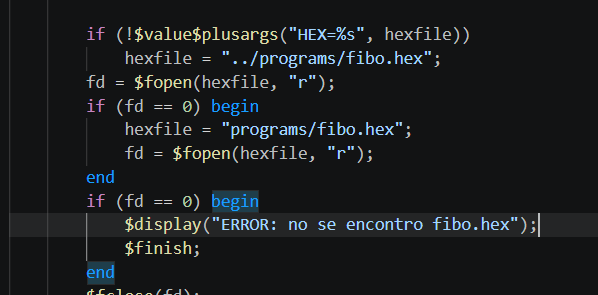

Simulation front-end compiling the RTL and sim/tb_fibo.v. All build products go to the output folder.

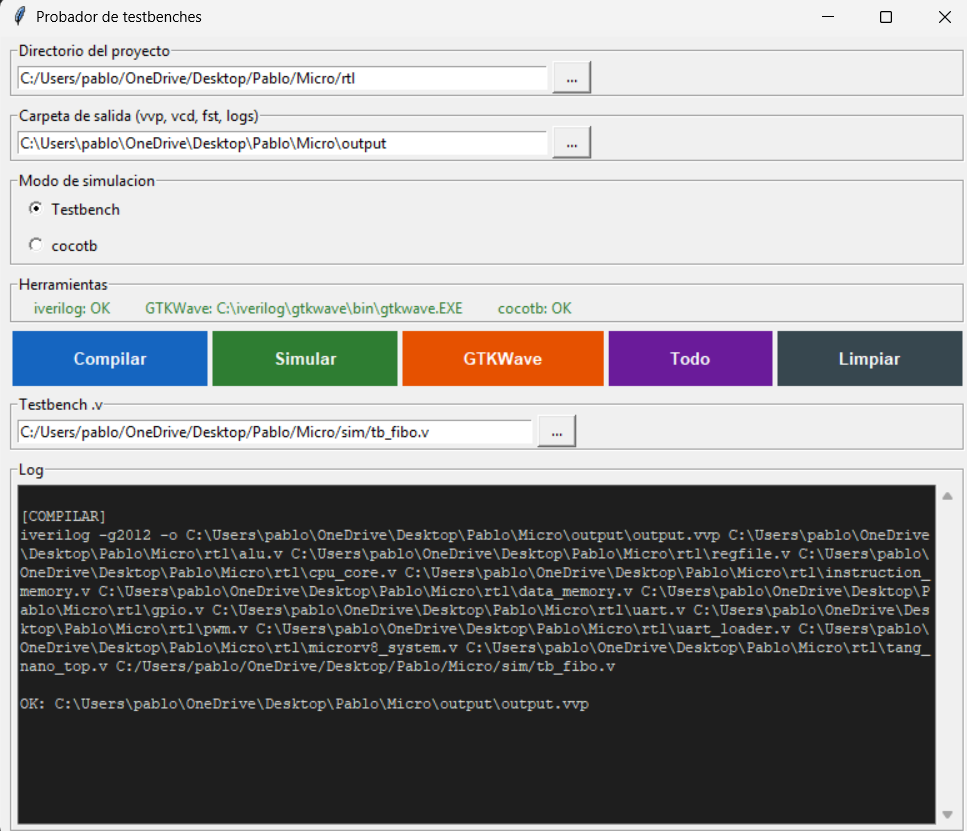

Result printed by the testbench for the Fibonacci program.

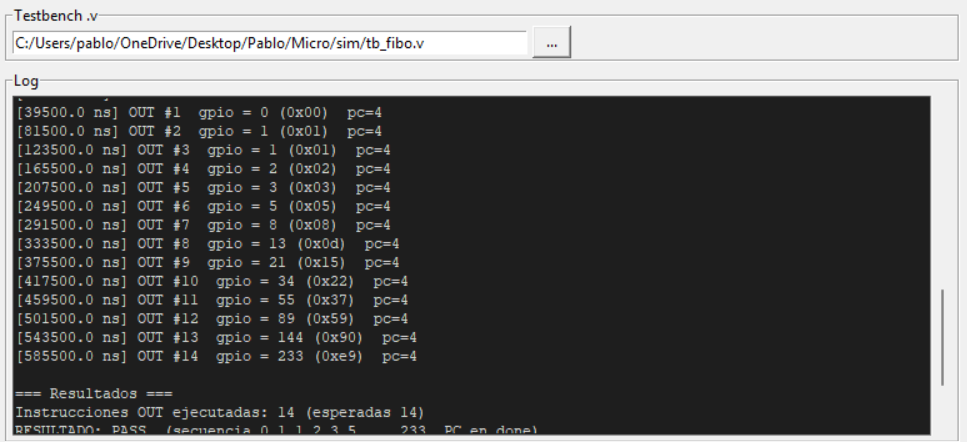

GTKWave: gpio_out going through the Fibonacci numbers.

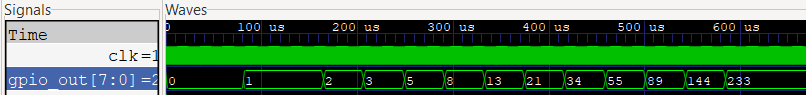

In [17]:
show("imgs/hex_fibo.png", "The hex file written by the IDE for the Fibonacci program: one instruction word per line.", 320)
show("imgs/llamada_fibo_tb.png", "Part of sim/tb_fibo.v that locates the hex file.", 560)
show("imgs/fibo_tb_compile.png", "Simulation front-end compiling the RTL and sim/tb_fibo.v. All build products go to the output folder.", 700)
show("imgs/fibo_tb_sim.png", "Result printed by the testbench for the Fibonacci program.", 700)
show("imgs/gtk_fibo.png", "GTKWave: gpio_out going through the Fibonacci numbers.", 760)

### The same program with cocotb

cocotb drives the same CPU from Python. The test `sim/cocotb/test_fibo.py` reads the hex file, plays the role of the instruction memory, lets the CPU run and checks three things: the sequence on `gpio_out`, that every loop iteration takes 7 instructions x 6 cycles = 42 clock cycles, and that the program counter ends at the final JUMP. It also stores the sampled signals, and `sim/cocotb/plot_fibo.py` turns them into the figures below. The simulation front-end runs these tests in its cocotb mode and writes everything to its output folder. cocotb is not needed to run this notebook.

cocotb mode of the front-end: the Fibonacci test reports PASSED.

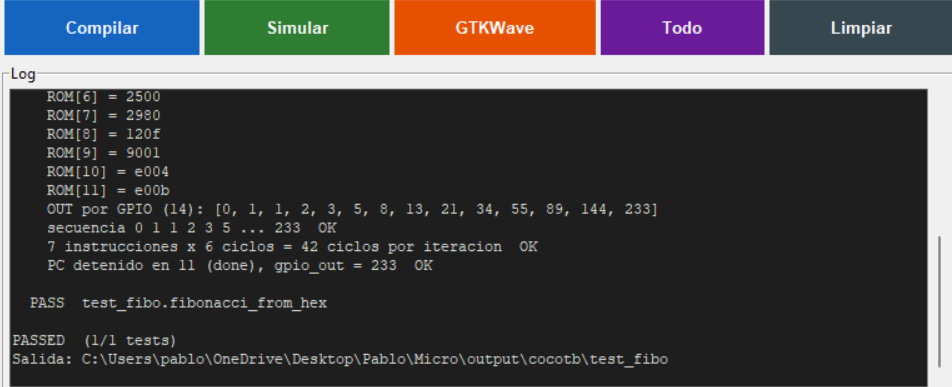

State, program counter and gpio_out sampled by the cocotb test. Every iteration takes 42 clock cycles.

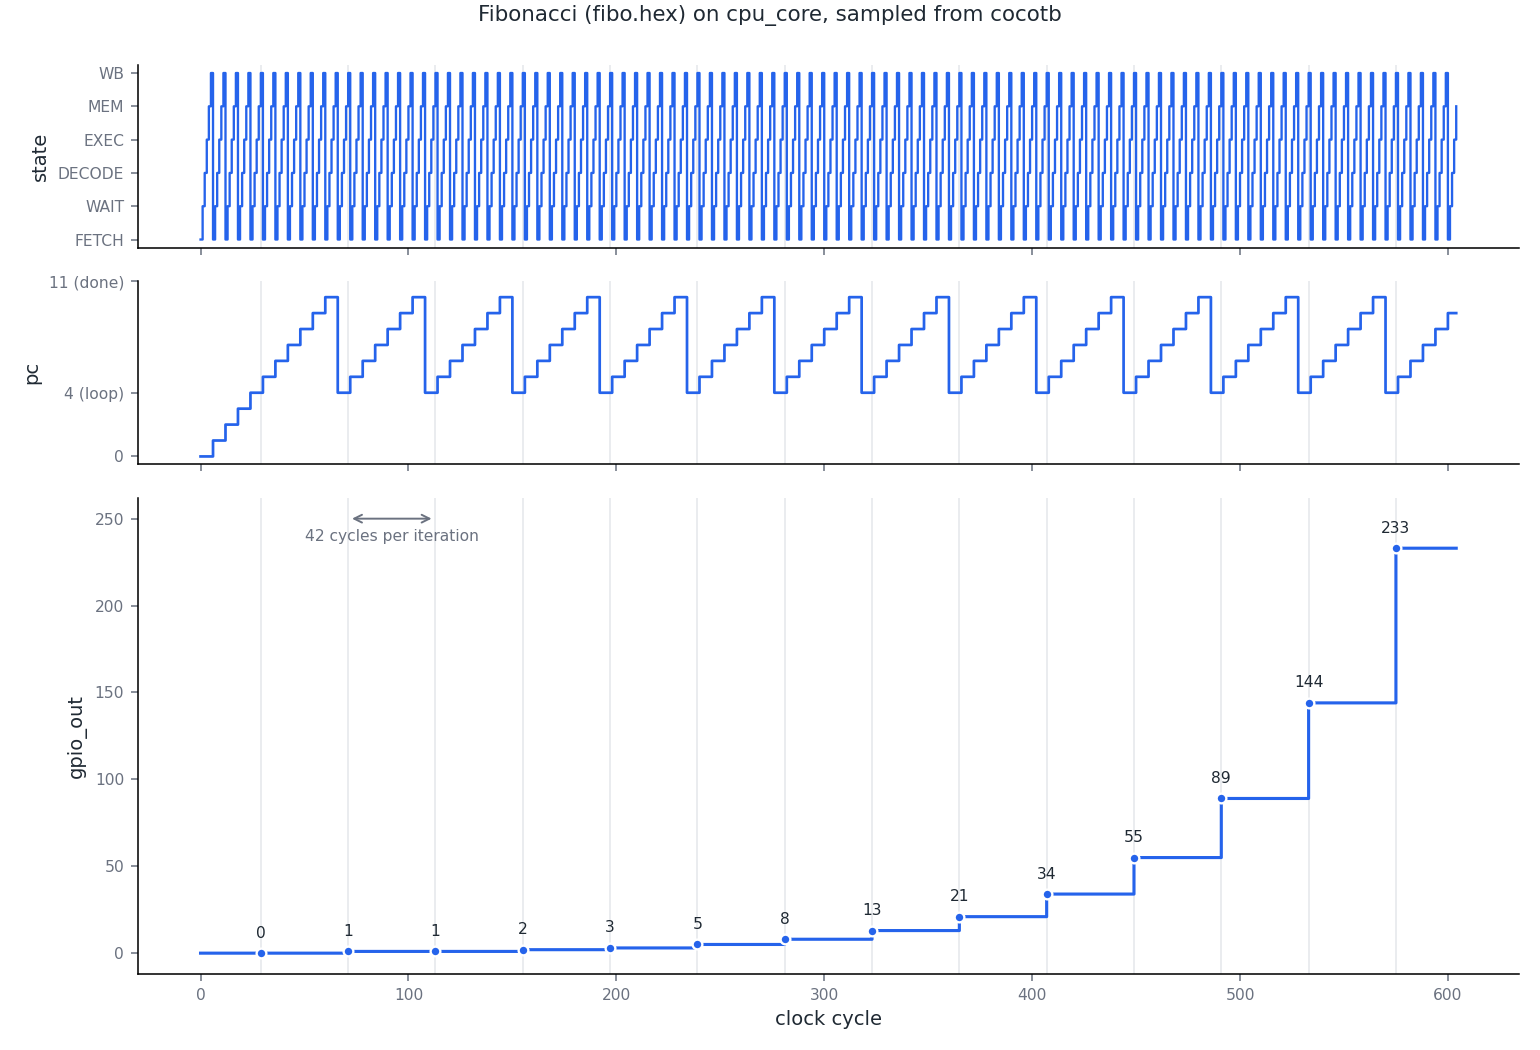

Spiral drawn from the values read from gpio_out: 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144 and 233.

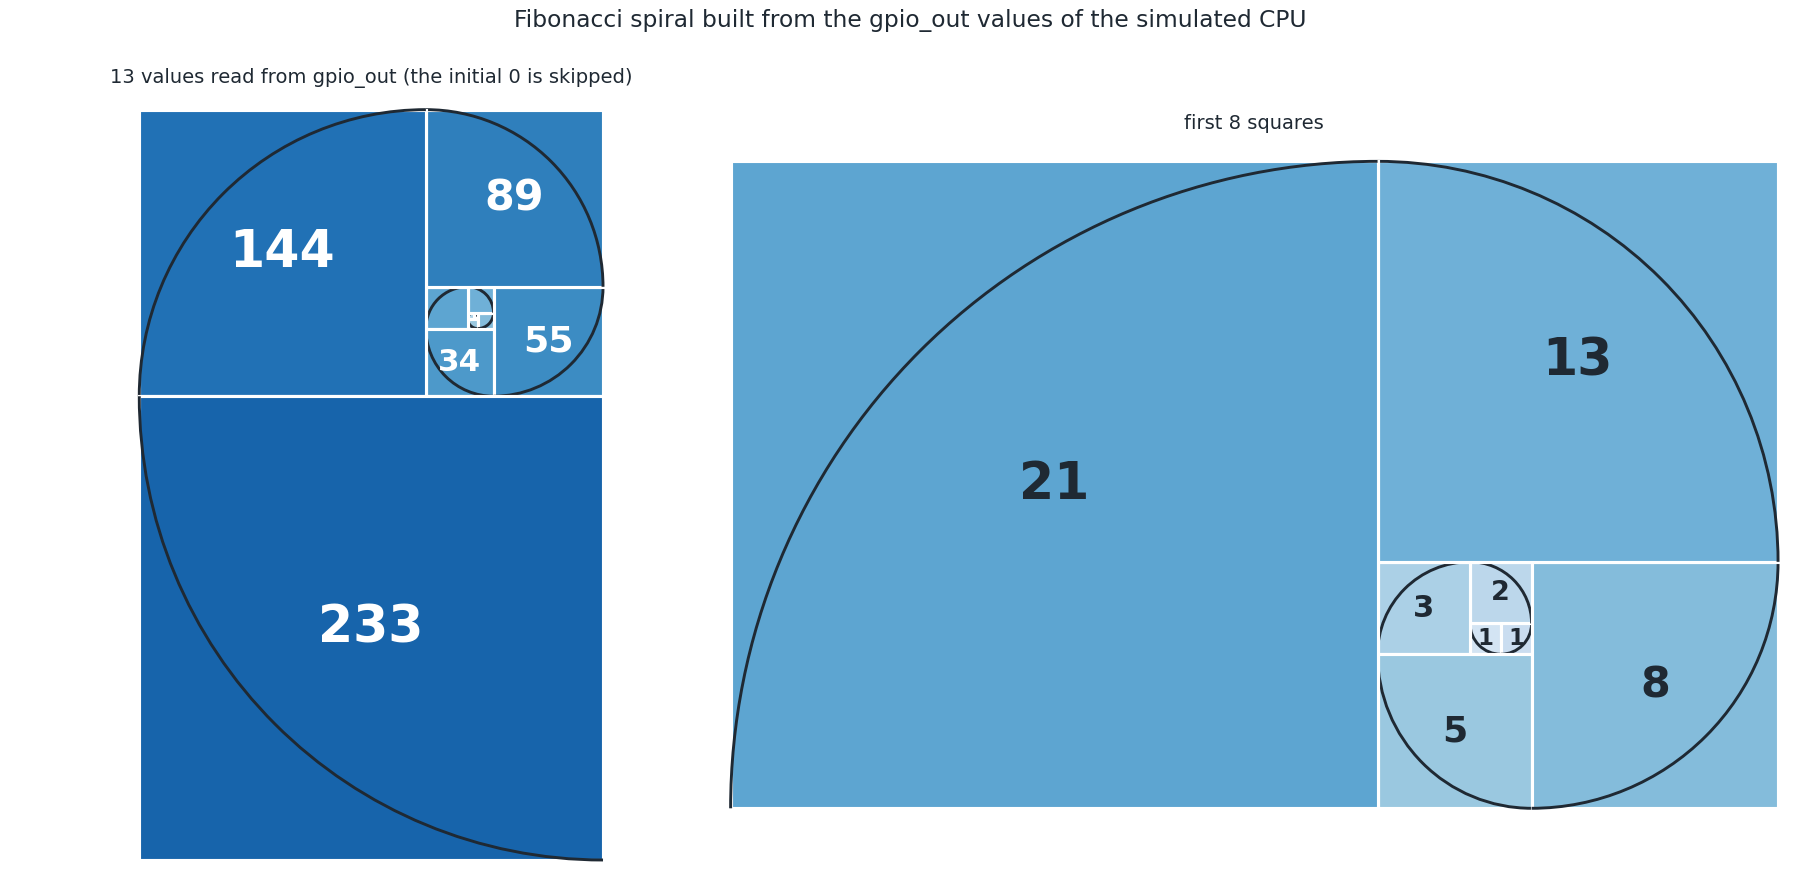

In [18]:
show("imgs/coco_fibo_sim.png", "cocotb mode of the front-end: the Fibonacci test reports PASSED.", 700)
show("imgs/fibo_trace.png", "State, program counter and gpio_out sampled by the cocotb test. Every iteration takes 42 clock cycles.", 900)
show("imgs/fibo_spiral.png", "Spiral drawn from the values read from gpio_out: 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144 and 233.", 900)

## 7. Peripherals: UART and PWM

### 7.1 UART transmitter

The CPU sends a byte by storing it at UART_TX (0x83). Because immediates are only 4 bits wide, the program builds each character code with ADDI and a shift (SLL), and it waits a fixed delay longer than one UART frame between characters. The program sends "Hola" and a newline in a loop, and the transmit pin is decoded with the same software receiver as before.

In [19]:
print((ROOT / "programs" / "demo_uart_hola.asm").read_text(encoding="utf-8")[:1100] + "   ...\n")
hola = run_demo("demo_uart_hola.asm", run_us=2500)
trh = Trace(hola["vcd"])
t_tx, y_tx = trh.sig("uart_tx_pin")
t_rxh, y_rxh = trh.sig("rx")
t_lah, y_lah = trh.sig("loader_active")
t_after = load_window(t_lah, y_lah)[1]
tx_frames = [f for f in decode_uart(t_tx, y_tx, t_from=t_after)]
text = bytes(b for _, b in tx_frames)
print("Bytes decoded from uart_tx_pin:", text)

    ADDI r4, r0, 4
    ADD  r3, r4, r4
    SLL  r3, r3, r4
    ADDI r3, r3, 3
loop:

    ADDI r1, r0, 4
    ADDI r6, r0, 4
    SLL  r1, r1, r6
    ADDI r1, r1, 7
    ADDI r1, r1, 1
    STORE r1, r3, 0
    ADDI r2, r0, 0
d_H:
    ADDI r2, r2, -1
    BEQ  r2, r0, e_H
    JUMP d_H
e_H:

    ADDI r1, r0, 6
    ADDI r6, r0, 4
    SLL  r1, r1, r6
    ADDI r1, r1, 7
    ADDI r1, r1, 7
    ADDI r1, r1, 1
    STORE r1, r3, 0
    ADDI r2, r0, 0
d_o:
    ADDI r2, r2, -1
    BEQ  r2, r0, e_o
    JUMP d_o
e_o:

    ADDI r1, r0, 6
    ADDI r6, r0, 4
    SLL  r1, r1, r6
    ADDI r1, r1, 7
    ADDI r1, r1, 5
    STORE r1, r3, 0
    ADDI r2, r0, 0
d_l:
    ADDI r2, r2, -1
    BEQ  r2, r0, e_l
    JUMP d_l
e_l:

    ADDI r1, r0, 6
    ADDI r6, r0, 4
    SLL  r1, r1, r6
    ADDI r1, r1, 1
    STORE r1, r3, 0
    ADDI r2, r0, 0
d_a:
    ADDI r2, r2, -1
    BEQ  r2, r0, e_a
    JUMP d_a
e_a:

    ADDI r1, r0, 0
    ADDI r6, r0, 4
    SLL  r1, r1, r6
    ADDI r1, r1, 7
    ADDI r1, r1, 3
    STORE r1, r3, 0

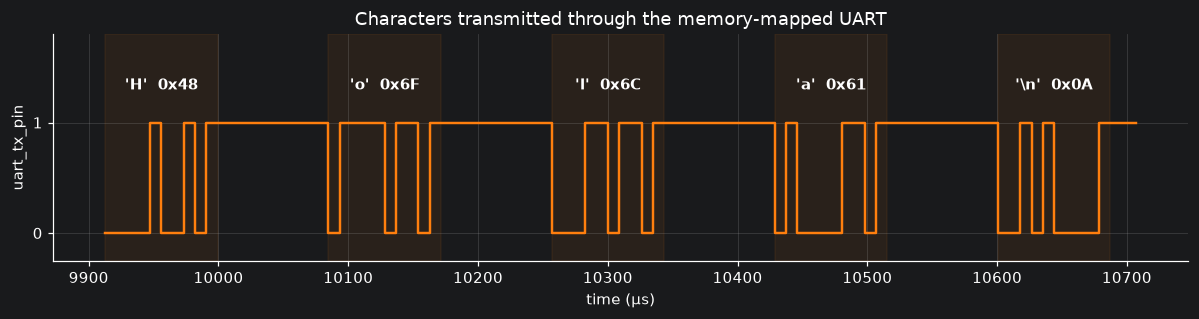

In [20]:
fig, ax = plt.subplots(figsize=(11, 3))
w0 = tx_frames[0][0] - 20
w1 = tx_frames[4][0] + 10 * BIT_US + 20
m = (t_tx >= w0) & (t_tx <= w1)
ax.step(np.append(t_tx[m], w1), np.append(y_tx[m], y_tx[m][-1]), where="post", color="#ff7f0e", lw=1.6)
for s, b in tx_frames[:5]:
    ax.axvspan(s, s + 10 * BIT_US, color="#ff7f0e", alpha=0.07)
    name = chr(b) if 32 <= b < 127 else "\\n"
    ax.text(s + 5 * BIT_US, 1.3, f"'{name}'  0x{b:02X}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(-0.25, 1.8); ax.set_yticks([0, 1]); ax.set_xlabel("time (µs)"); ax.set_ylabel("uart_tx_pin")
ax.set_title("Characters transmitted through the memory-mapped UART")
plt.tight_layout(); plt.show()

Figure 6. Transmission of the characters through the memory-mapped UART at 115200 baud.

### 7.2 PWM

The PWM is configured with three stores: PWM_PRE, PWM_CTRL and PWM_DUTY. The demo uses a prescaler of 1 and three duty values, 64, 128 and 192 out of 256, each one held for about 170 µs. The duty cycle and the period are measured from the waveform.

duty   25% requested ->  measured  25.0%   period 9.48 µs (105.5 kHz)   (35 periods)
duty   50% requested ->  measured  50.0%   period 9.48 µs (105.5 kHz)   (18 periods)
duty   75% requested ->  measured  75.0%   period 9.48 µs (105.5 kHz)   (18 periods)


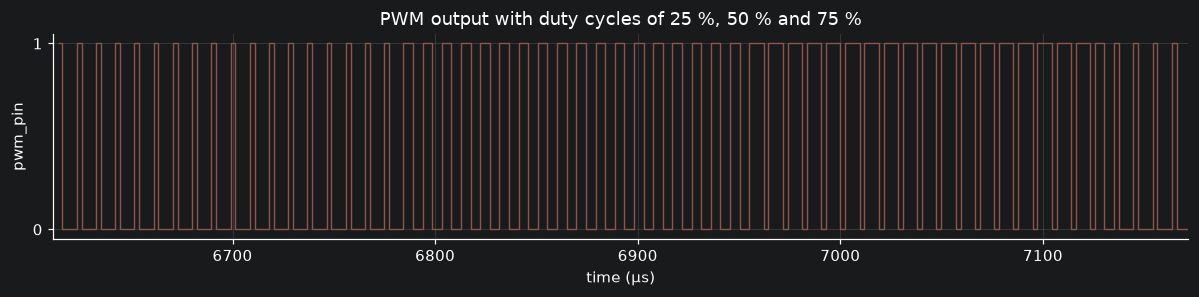

In [21]:
pwm = run_demo("demo_pwm.asm", run_us=700)
trp = Trace(pwm["vcd"])
t_pw, y_pw = trp.sig("pwm_pin")
t_lap, y_lap = trp.sig("loader_active")
t_start = load_window(t_lap, y_lap)[1]

rise = t_pw[(y_pw == 1) & (t_pw > t_start)]
fall = t_pw[(y_pw == 0) & (t_pw > t_start)]
rows = []
for r0, r1 in zip(rise[:-1], rise[1:]):
    f = fall[(fall > r0) & (fall < r1)]
    if len(f):
        rows.append((r0, r1 - r0, (f[0] - r0) / (r1 - r0)))
rows = np.array(rows)

for target in (0.25, 0.50, 0.75):
    sel = rows[np.abs(rows[:, 2] - target) < 0.04]
    if len(sel):
        print(f"duty {target*100:4.0f}% requested ->  measured {np.median(sel[:, 2])*100:5.1f}%   "
              f"period {np.median(sel[:, 1]):.2f} µs ({1000/np.median(sel[:, 1]):.1f} kHz)   ({len(sel)} periods)")

fig, ax = plt.subplots(figsize=(11, 2.8))
m = t_pw > t_start
ax.step(t_pw[m], y_pw[m], where="post", color="#8c564b", lw=0.9)
ax.set_xlim(t_start, t_start + 560)
ax.set_xlabel("time (µs)"); ax.set_ylabel("pwm_pin"); ax.set_yticks([0, 1])
ax.set_title("PWM output with duty cycles of 25 %, 50 % and 75 %")
plt.tight_layout(); plt.show()

## 8. Development tools and simulation front-end

The platform comes with two desktop tools that cannot run inside a notebook, so they are shown with screenshots. The same steps are available from the command line, and that is what this notebook runs.

### 8.1 JoJoP IDE

JoJoP IDE (`JoJoP_IDE.py`) is a PyQt5 editor to write, assemble and flash programs. It has syntax highlighting by instruction type, a library of example programs, a serial port selector with one-click flashing through the protocol of section 4, an assembler log and configurable themes.

JoJoP IDE: start screen.

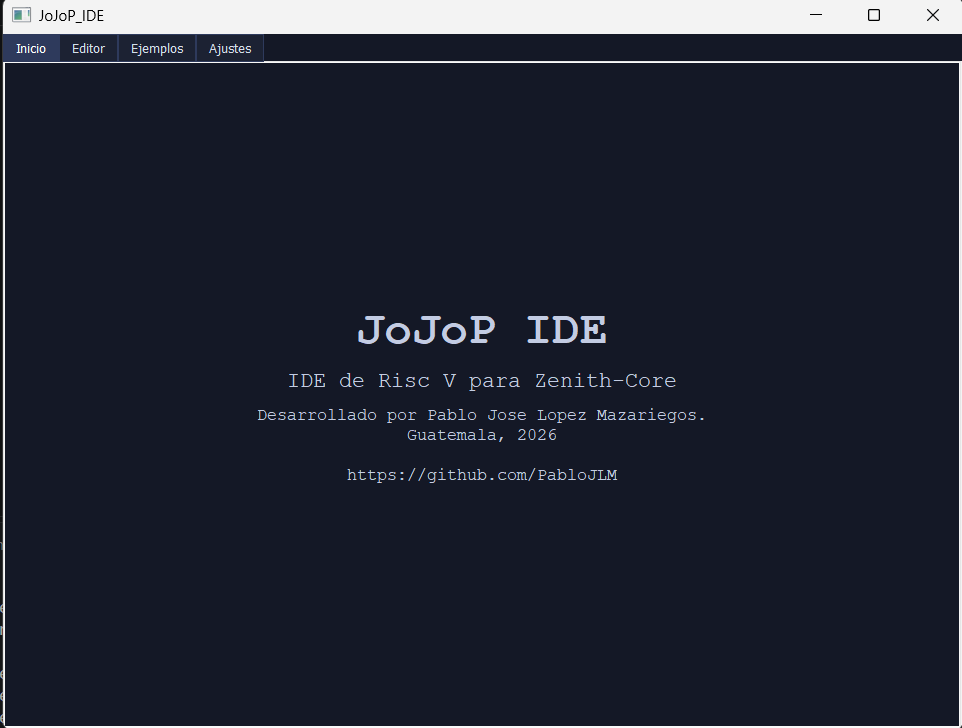

JoJoP IDE: editor with the Fibonacci program, compile and flash buttons and the serial port selector.

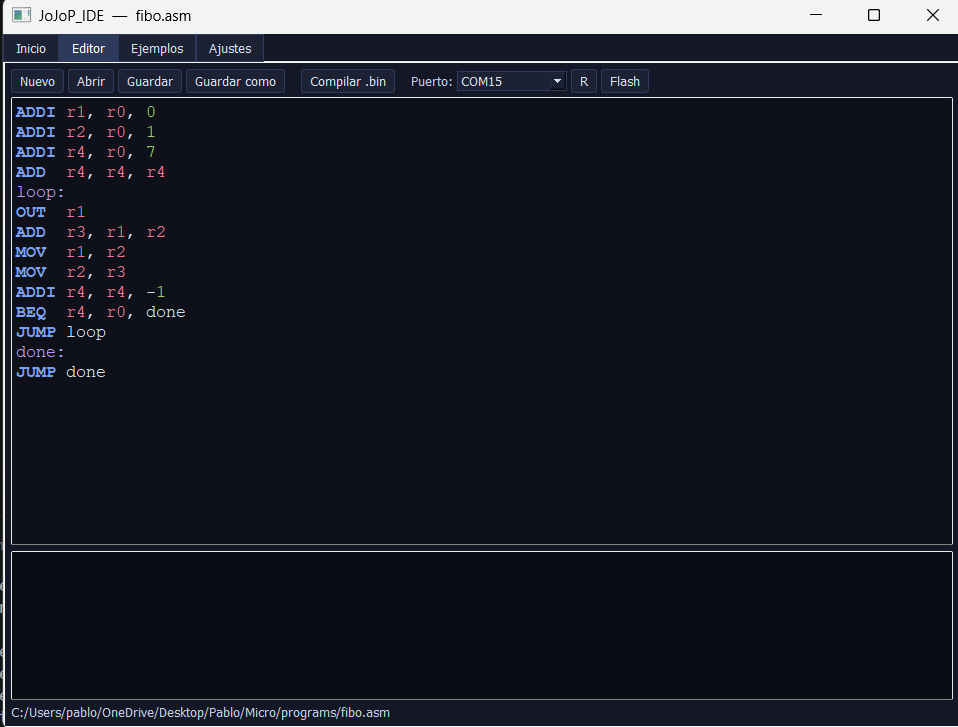

JoJoP IDE: library of example programs.

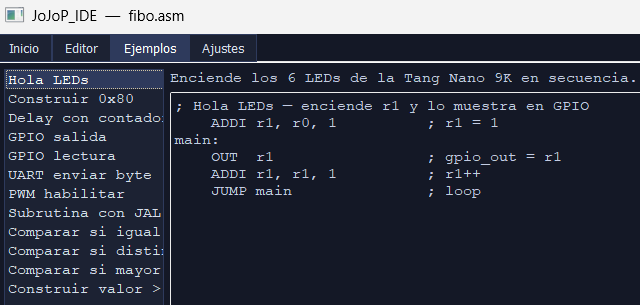

JoJoP IDE: Solarized theme and the settings page (themes, font, mascot, background image, tool paths).

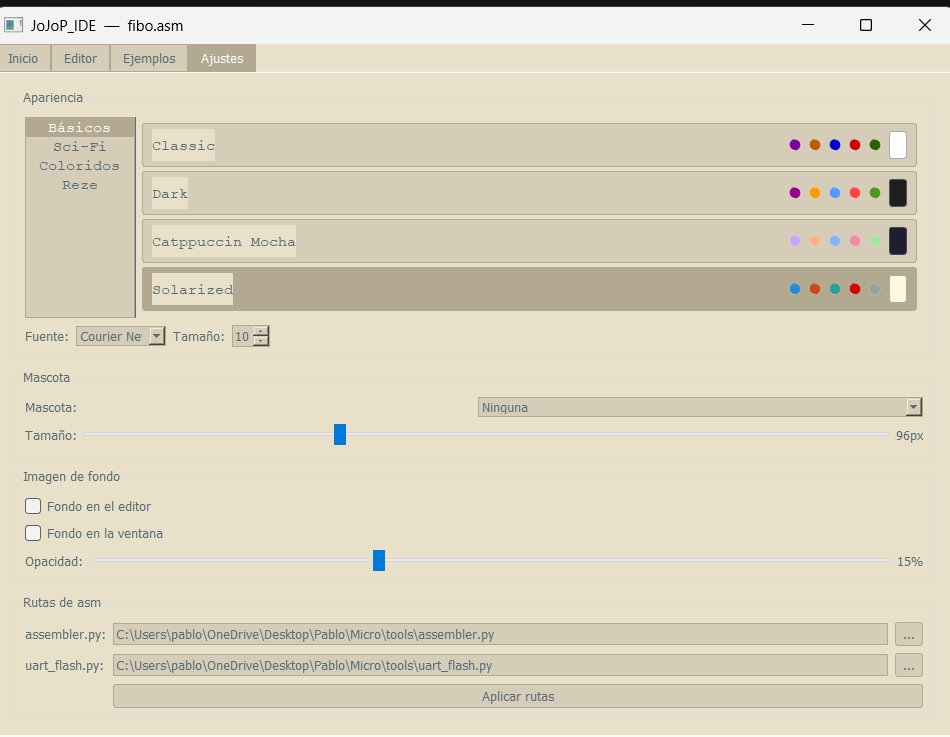

JoJoP IDE: Matrix theme.

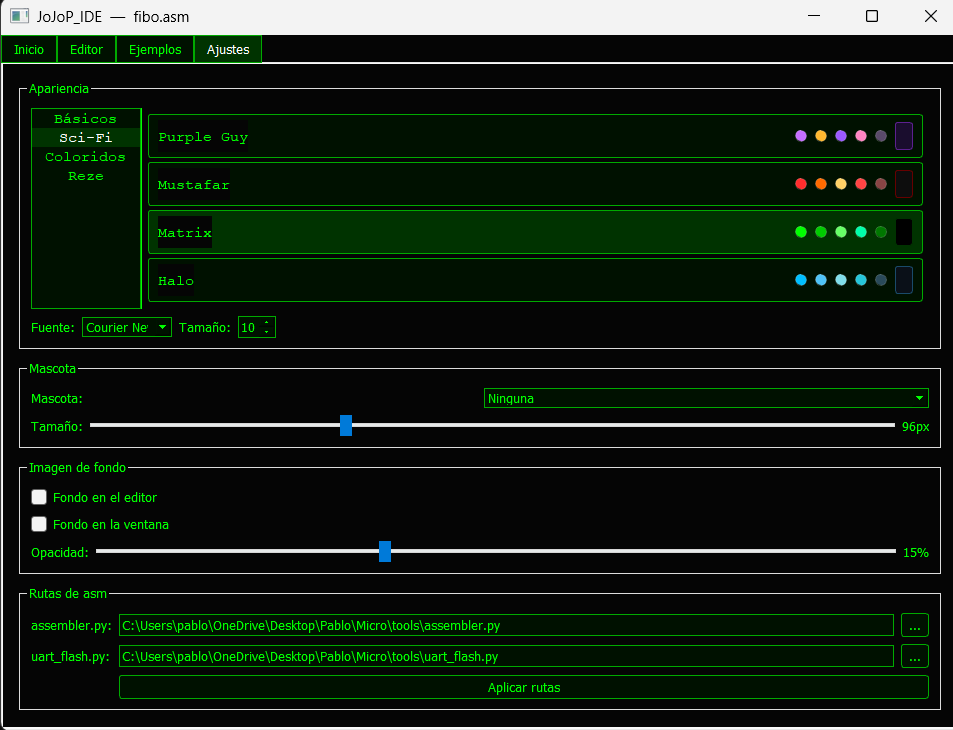

In [22]:
show("imgs/caratula_ide.png", "JoJoP IDE: start screen.", 640)
show("imgs/fibo_ide.png", "JoJoP IDE: editor with the Fibonacci program, compile and flash buttons and the serial port selector.", 640)
show("imgs/ejemplos_ide.png", "JoJoP IDE: library of example programs.", 560)
show("imgs/tema1_ide.png", "JoJoP IDE: Solarized theme and the settings page (themes, font, mascot, background image, tool paths).", 640)
show("imgs/tema2_ide.png", "JoJoP IDE: Matrix theme.", 640)

### 8.2 Simulation front-end: testbench mode

The simulation front-end (`sim_gui.py`) is a Tkinter application that compiles the RTL with Icarus Verilog, runs a testbench and opens the resulting waveform in GTKWave. The compiled file, the waveforms and the logs are written to an output folder that can be chosen in the window, so the source folders stay clean.

Front-end: compiling the RTL together with sim/tb_cpu.v.

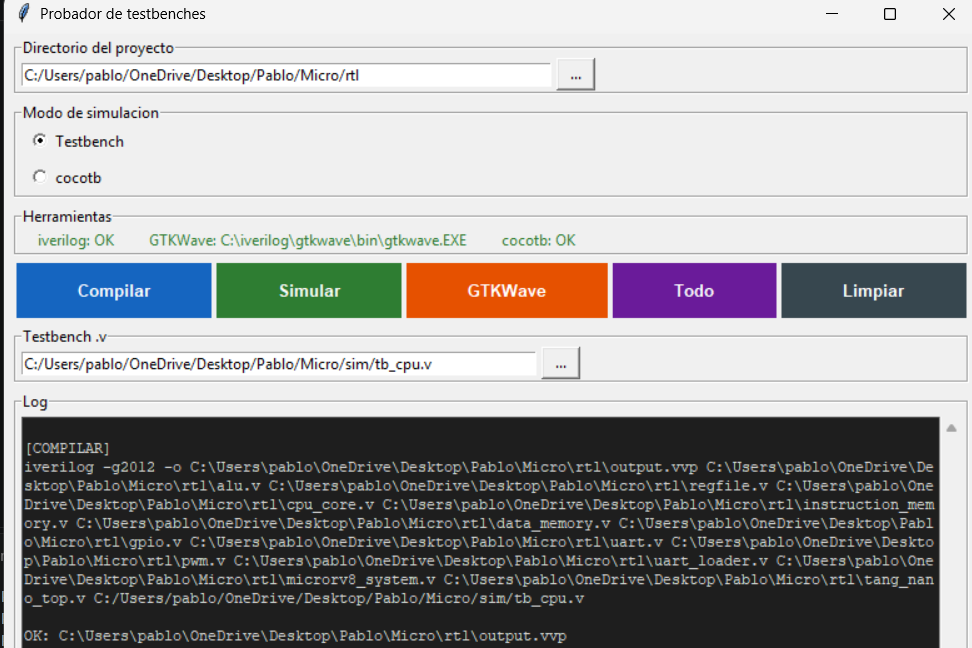

Front-end: result of the CPU unit testbench.

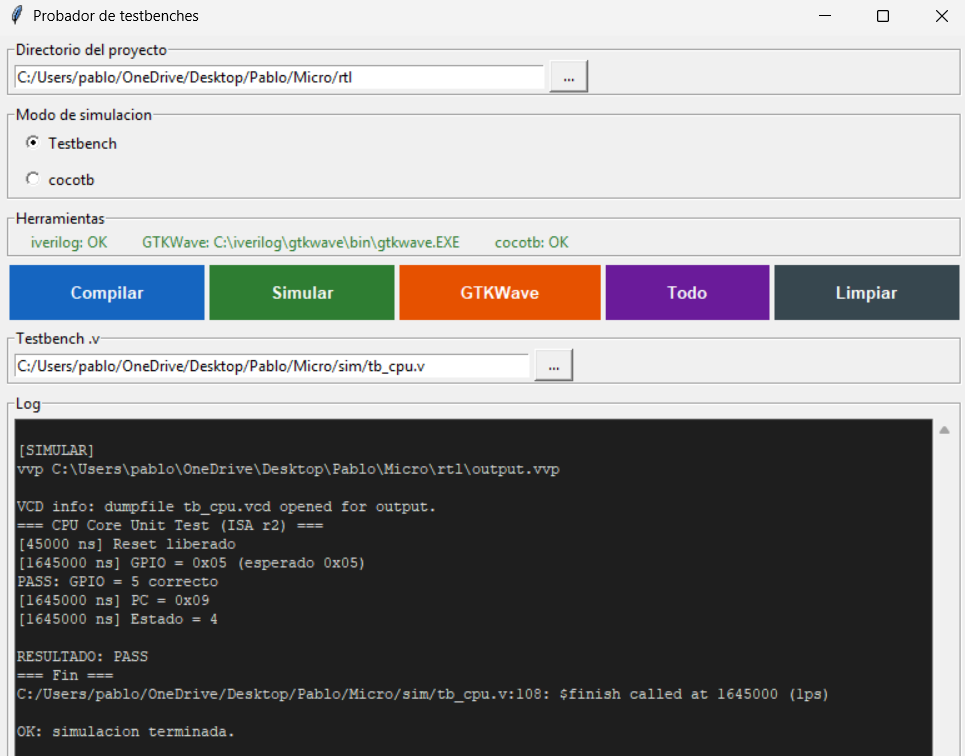

GTKWave opened from the front-end: instruction, program counter and gpio_out of the CPU test.

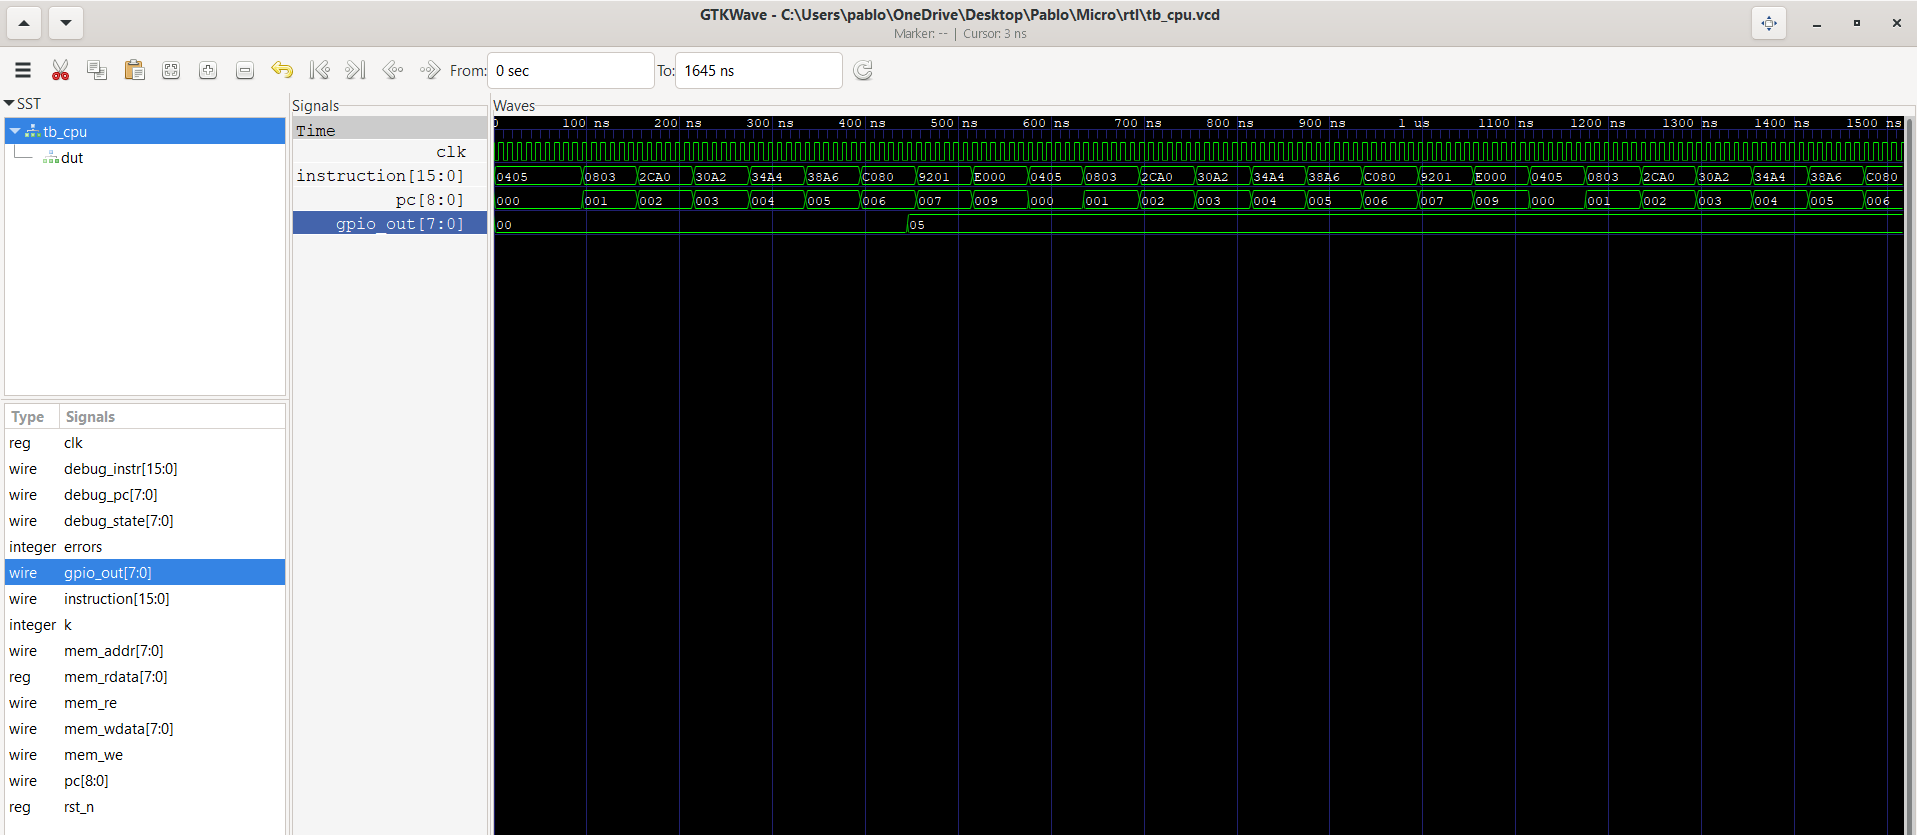

In [23]:
show("imgs/tb_cpu_compile.png", "Front-end: compiling the RTL together with sim/tb_cpu.v.", 640)
show("imgs/tb_cpu_sim.png", "Front-end: result of the CPU unit testbench.", 640)
show("imgs/gtk_cpu.png", "GTKWave opened from the front-end: instruction, program counter and gpio_out of the CPU test.", 900)

### 8.3 Simulation front-end: cocotb mode

In its second mode the front-end builds the design and runs a cocotb test with the runner of cocotb. The log shows each check of the test and ends with PASSED or FAILED.

cocotb mode: test file and top module selected, and the result of the CPU test.

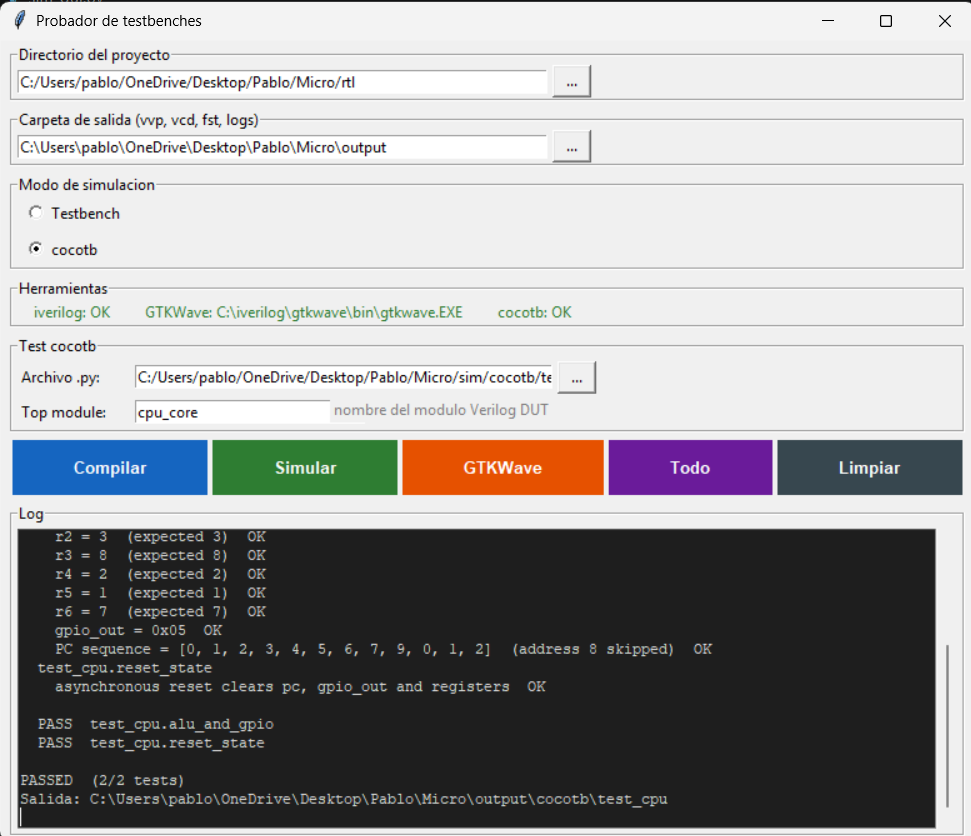

Signals sampled by the cocotb test of the CPU: state, program counter, registers and gpio_out.

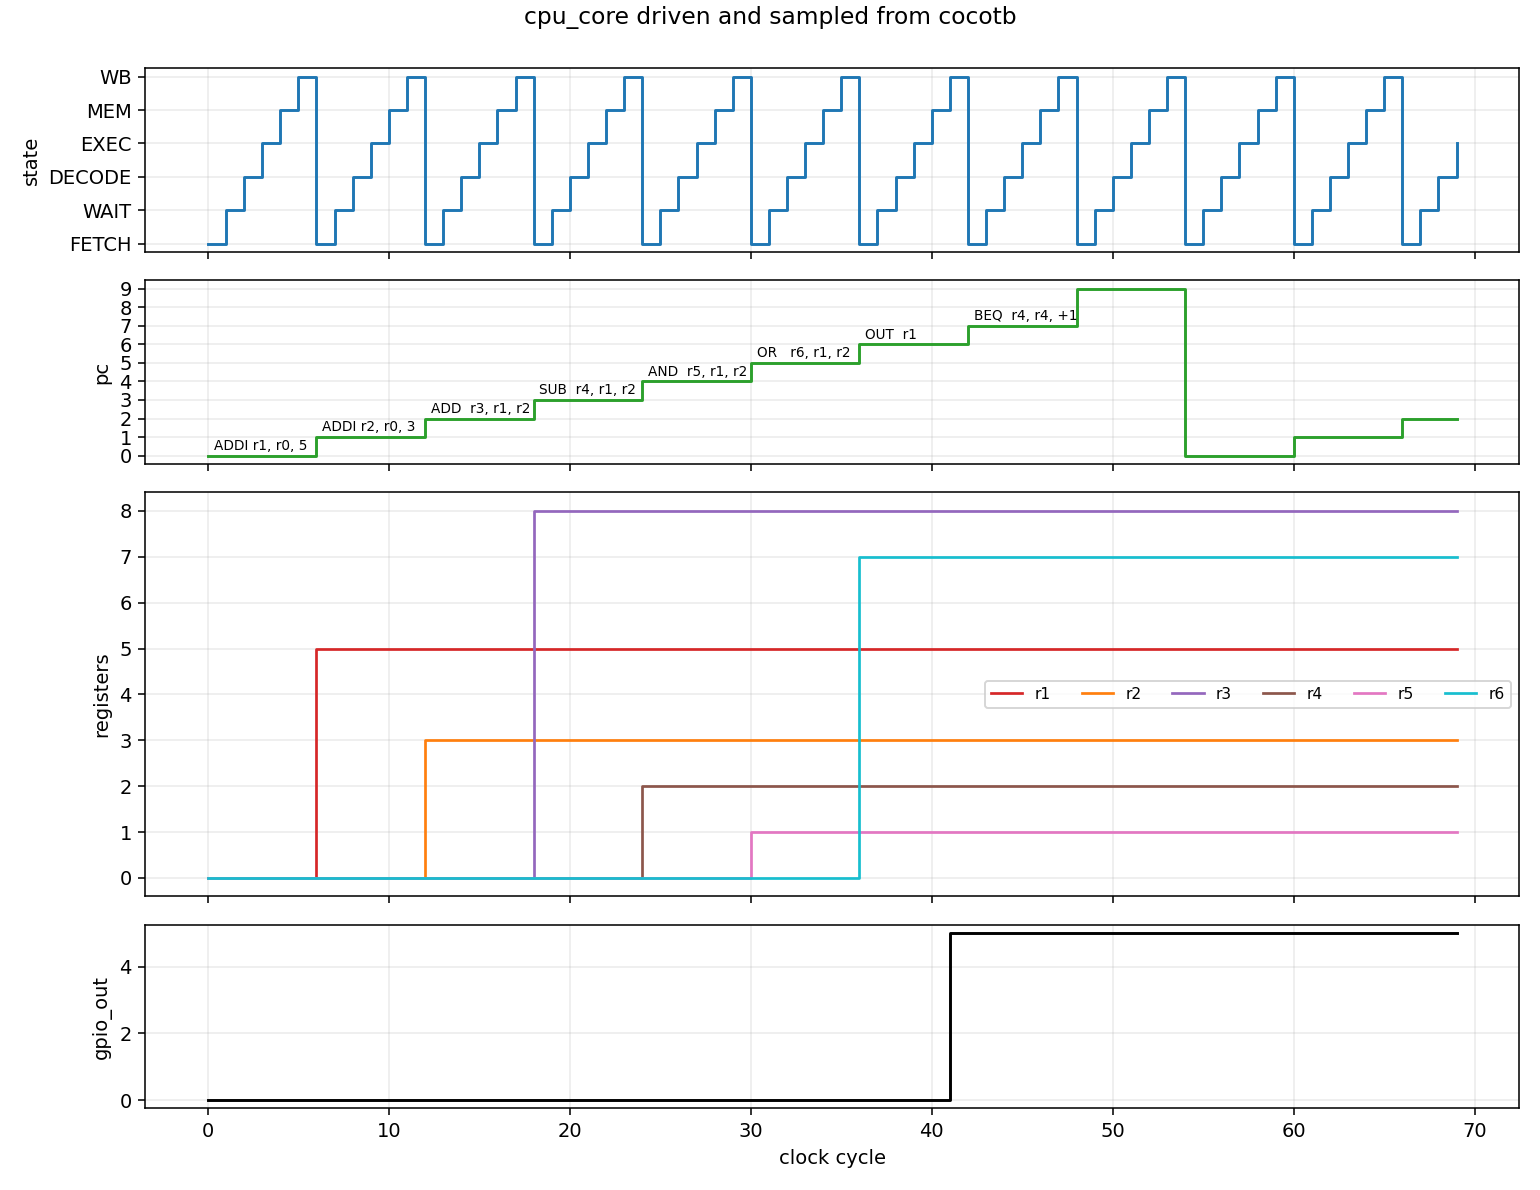

In [24]:
show("imgs/coco_cpu.png", "cocotb mode: test file and top module selected, and the result of the CPU test.", 640)
show("imgs/cocotb_trace.png", "Signals sampled by the cocotb test of the CPU: state, program counter, registers and gpio_out.", 900)

## 9. Hardware validation

The design runs on a Sipeed Tang Nano 9K (Gowin GW1NR-9C, 8640 LUTs, 27 MHz). Programs are loaded over the board's USB-UART, with `tools/uart_flash.py` or from the IDE, without synthesising again. The pin assignments are in `rtl/tang_nano_9k.cst`.

| Pin | Signal |
|---|---|
| 17 | UART RX (program loading) |
| 18 | UART TX |
| 25 | PWM output |
| 10 to 15 | LED 0 to 5, active low (GPIO bits 0 to 5) |
| S1 | Reset, active low |

Resource usage reported by Gowin EDA after synthesis:

| Resource | Used | Available | % |
|---|---|---|---|
| Logic (LUT + ALU) | 752 | 8640 | 9 |
| Registers | 388 | 6693 | 6 |
| BSRAM | 2 | 26 | 8 |

The CPU uses less than a tenth of the device. Synthesis for this FPGA uses Gowin EDA, which is free to use but not open source. Everything else in this notebook uses open-source tools.

Gowin EDA project wizard: target device GW1NR-9, package QFN88P.

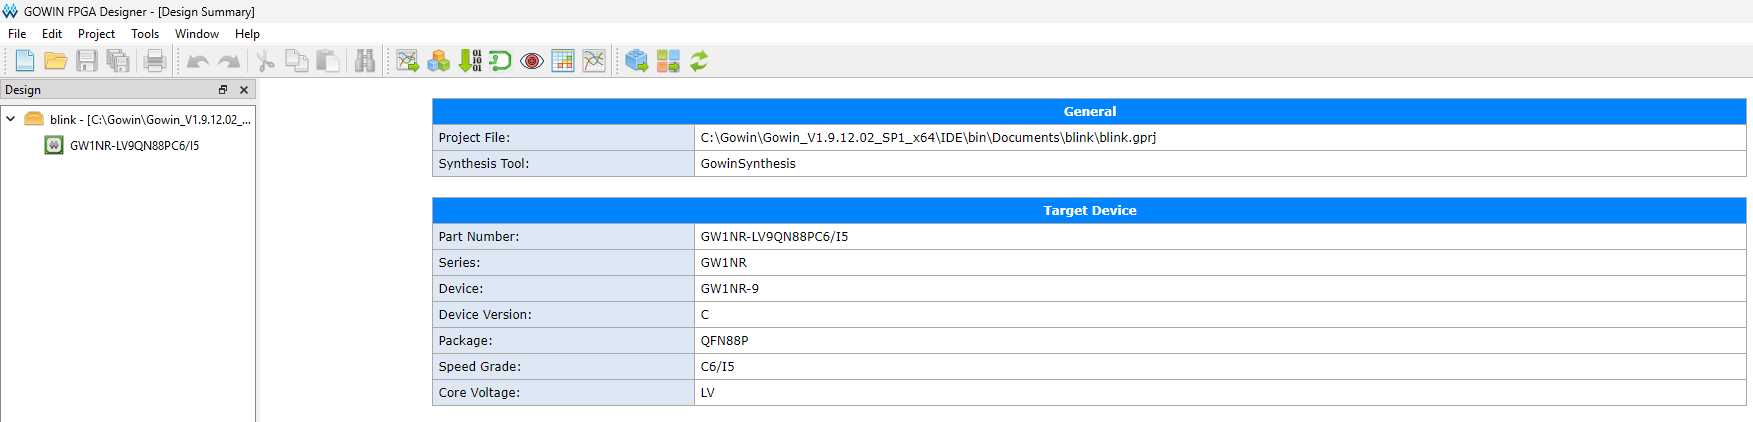

Gowin EDA design summary of the blink example project.

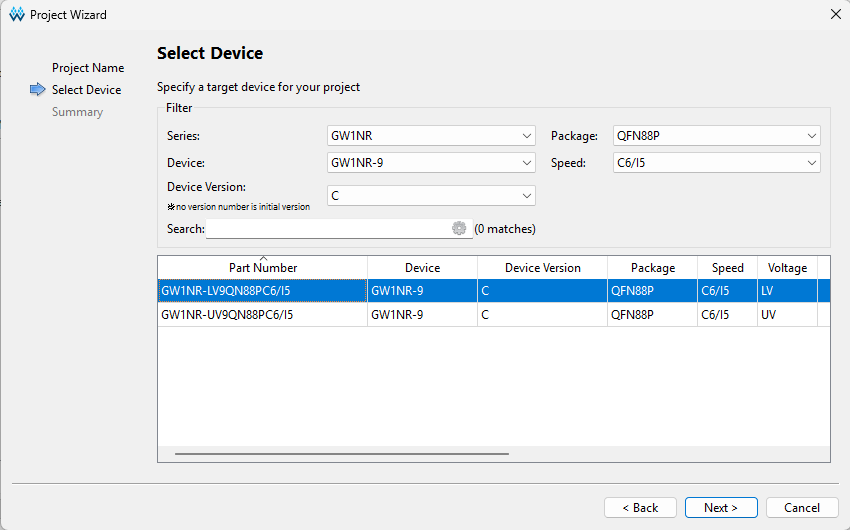

Gowin FloorPlanner: I/O constraints of the LED outputs in the blink example.

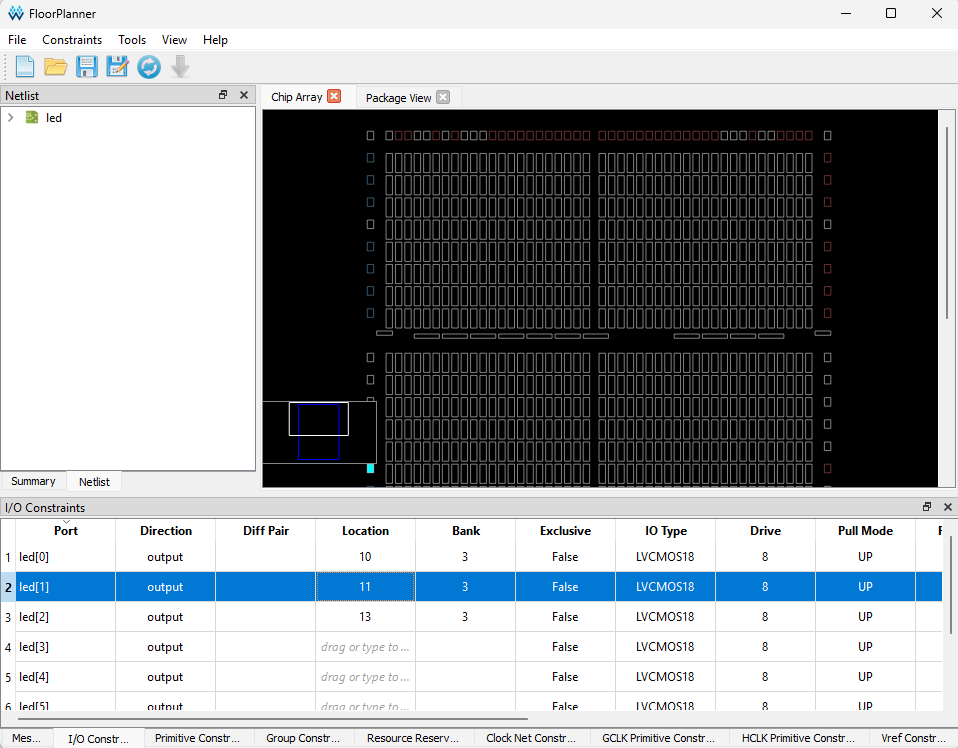

In [25]:
show("imgs/targetdevice.png", "Gowin EDA project wizard: target device GW1NR-9, package QFN88P.", 640)
show("imgs/seleccion.png", "Gowin EDA design summary of the blink example project.", 900)
show("imgs/ruteo.png", "Gowin FloorPlanner: I/O constraints of the LED outputs in the blink example.", 640)

show("imgs/placa.jpg", "Tang Nano 9K board running Zenith Core.", 520)
show("imgs/gowin_recursos.png", "Resource report from Gowin EDA.", 640)
show("imgs/terminal_hola.png", "Serial terminal receiving the text sent by the CPU.", 640)

demo = ROOT / "imgs" / "demo.gif"
if demo.exists() and demo.stat().st_size < 8_000_000:
    show("imgs/demo.gif", "Binary counter on the board after being loaded over the UART.", 480)

## 10. Limitations and future work

* Synthesis. Only Gowin EDA has been used so far. A Yosys run on the same RTL and, time permitting, an OpenLane flow with Sky130 are planned.
* Not implemented: interrupts, a hardware multiplier, wider immediates.

## References

1. Zenith Core repository: https://github.com/PabloJLM/Zenith-Core
2. Icarus Verilog: https://steveicarus.github.io/iverilog/
3. GTKWave: https://gtkwave.sourceforge.net/
4. Sipeed Tang Nano 9K: https://wiki.sipeed.com/hardware/en/tang/Tang-Nano-9K/Nano-9K.html
5. A. Waterman and K. Asanovic (eds.), The RISC-V Instruction Set Manual
6. IEEE SSCS Code-a-Chip: https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io

Released under the Apache License 2.0.